# NHIS Part I: Modeling Cost-Related Mental Health Care Barriers

The Part I classification task predicts whether an adult delayed counseling or therapy, or needed counseling or therapy but did not receive it, because of cost.

The target is not a diagnosis. It represents a cost-related access barrier to mental health care.

The modeling goal is to compare interpretable and higher-performing classification models while keeping the feature choices tied to the codebook, cleaning decisions, and project question.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

## File paths

The same folder structure works locally in PyCharm and in Colab. The Colab mount code is included as a comment for later use.

In [2]:
# Colab option, leave commented out when working locally in PyCharm.
# from google.colab import drive
# drive.mount("/content/drive")
# PROJECT_ROOT = Path("/content/drive/MyDrive/med_project")

# Local/PyCharm option.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Interim data folder:", DATA_INTERIM)
print("Processed data folder:", DATA_PROCESSED)

Project root: C:\Users\Alexi\projects\med_project
Interim data folder: C:\Users\Alexi\projects\med_project\data\interim
Processed data folder: C:\Users\Alexi\projects\med_project\data\processed


## Load the merged NHIS analytic file

The modeling file comes from the cleaned Sample Adult, imputed income, and paradata merge. The target was already created and checked in the cleaning notebooks.

In [3]:
nhis_path = DATA_INTERIM / "nhis_adult_income_paradata_merged_clean.csv"

nhis = pd.read_csv(nhis_path, low_memory=False)

print("NHIS merged shape:", nhis.shape)
nhis.head()

NHIS merged shape: (28777, 79)


,HHX,WTFA_A,PSTRAT,PPSU,MHTHDLY_A,MHTHND_A,mental_health_cost_barrier,AGEP_A,SEX_A,HISPALLP_A,...,MODE_P,MODE_T,TOTCOUNT,INTMODESA,INTMODEWHYSA,INTLANGSA,SASTRPNT,SA_TOD,personal_visit_contact_share,telephone_contact_share
0,H029691,7371.139,103,2,2,2,0,67.0,1.0,3,...,1.0,0.0,1.0,3.0,NaN,1.0,1.0,2.0,1.000000,0.000000
1,H028812,3146.794,122,2,2,2,0,73.0,1.0,2,...,1.0,0.0,1.0,3.0,NaN,1.0,1.0,2.0,1.000000,0.000000
2,H045277,10807.558,122,2,2,2,0,48.0,1.0,3,...,4.0,1.0,5.0,3.0,NaN,1.0,3.0,1.0,0.800000,0.200000
3,H021192,4661.643,122,2,2,2,0,42.0,2.0,2,...,2.0,9.0,11.0,1.0,1.0,1.0,3.0,1.0,0.181818,0.818182
4,H025576,10929.554,122,2,2,2,0,50.0,2.0,2,...,4.0,3.0,7.0,1.0,1.0,1.0,3.0,3.0,0.571429,0.428571


## NHIS survey design and target balance

NHIS is not a simple random sample. It is a nationally representative household survey of the civilian noninstitutionalized U.S. population. The 2023 design uses geographically clustered sampling, and the public-use file includes survey design variables for weighted estimation and variance estimation.

For the Sample Adult file, `WTFA_A` is the final annual Sample Adult weight. `PSTRAT` is the public-use pseudo-stratum variable, and `PPSU` is the public-use pseudo-PSU variable. These variables are retained for descriptive checks and documentation, but they are not used as model predictors.

The machine learning train/test split is also stratified, but that is a separate modeling step. In the modeling split, stratification only means the target distribution is kept similar in the training and test sets.

The positive class is small, so accuracy alone is not enough. Evaluation includes AUC, average precision, recall, precision, F1-score, threshold review, and lift-style checks.

In [4]:
target_col = "mental_health_cost_barrier"

target_counts = nhis[target_col].value_counts(dropna=False).sort_index()
target_rates = nhis[target_col].value_counts(normalize=True, dropna=False).sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "proportion": target_rates
})

target_summary

,count,proportion
mental_health_cost_barrier,,
0,26945,0.936338
1,1832,0.063662


In [5]:
design_cols = ["WTFA_A", "PSTRAT", "PPSU"]

for col in design_cols:
    if col in nhis.columns:
        print(f"{col}: present")
    else:
        print(f"{col}: missing")

if {"PSTRAT", "PPSU"}.issubset(nhis.columns):
    print("\nSurvey design check:")
    print("Number of public-use pseudo-strata:", nhis["PSTRAT"].nunique())
    print("Number of public-use pseudo-PSUs:", nhis["PPSU"].nunique())

if "WTFA_A" in nhis.columns:
    print("\nSample Adult weight check:")
    print(nhis["WTFA_A"].describe())

WTFA_A: present
PSTRAT: present
PPSU: present

Survey design check:
Number of public-use pseudo-strata: 52
Number of public-use pseudo-PSUs: 108

Sample Adult weight check:
count    28777.000000
mean      8741.974803
std       5695.356607
min       1792.441000
25%       4643.690000
50%       7368.915000
75%      10981.460000
max      39925.600000
Name: WTFA_A, dtype: float64


## Weighted target check

The unweighted target distribution is useful for machine learning because the models train on observed records. The weighted target rate is useful for describing the represented Sample Adult population.

This weighted check uses `WTFA_A`, the final annual Sample Adult weight. The weight is not used as a model predictor.

In [6]:
if "WTFA_A" in nhis.columns:
    unweighted_positive_rate = nhis[target_col].mean()

    weighted_positive_rate = np.average(
        nhis[target_col],
        weights=nhis["WTFA_A"]
    )

    target_weight_check = pd.DataFrame({
        "measure": [
            "Unweighted positive rate",
            "Weighted positive rate using WTFA_A",
        ],
        "rate": [
            unweighted_positive_rate,
            weighted_positive_rate,
        ],
    })

    print(target_weight_check)
else:
    print("WTFA_A is not available for the weighted target check.")

                               measure      rate
0             Unweighted positive rate  0.063662
1  Weighted positive rate using WTFA_A  0.067240


## Poverty and feature engineering

Poverty is treated as a category in the main model. The imputed income file gives a detailed poverty category, but the first model uses a grouped version to keep the feature readable and reduce sparse categories.

The grouped poverty feature keeps more information than a binary poor/non-poor split. A multidimensional poverty index is not used because the NHIS file does not contain the full deprivation structure needed to build one responsibly.

The first feature engineering pass creates a small set of summary features tied to the project question:

- chronic condition count
- mental health history count
- functioning difficulty count
- affordability pressure count
- grouped poverty category

These summaries reduce redundancy by replacing several related raw variables with clearer grouped features.

In [7]:
nhis_fe = nhis.copy()

In [8]:
def group_poverty_category(value):
    if pd.isna(value):
        return "Unknown"

    value = int(value)

    if value in [1, 2, 3]:
        return "Poor: below 100% FPL"
    if value == 4:
        return "Near poor: 100% to <125% FPL"
    if value in [5, 6, 7]:
        return "Low income: 125% to <200% FPL"
    if value in [8, 9, 10, 11]:
        return "Middle income: 200% to <400% FPL"
    if value in [12, 13, 14]:
        return "High income: 400%+ FPL"

    return "Unknown"


nhis_fe["poverty_group_imp"] = nhis_fe["RATCAT_A_imp"].apply(group_poverty_category)

nhis_fe["poverty_group_imp"].value_counts(dropna=False)

poverty_group_imp
High income: 400%+ FPL              12064
Middle income: 200% to <400% FPL     8450
Low income: 125% to <200% FPL        4100
Poor: below 100% FPL                 3045
Near poor: 100% to <125% FPL         1118
Name: count, dtype: int64

In [9]:
chronic_condition_cols = [
    "HYPEV_A",
    "CHLEV_A",
    "DIBEV_A",
    "COPDEV_A",
    "ARTHEV_A",
    "ASEV_A",
    "CANEV_A",
    "STREV_A",
    "CHDEV_A",
]

mental_health_history_cols = [
    "ANXEV_A",
    "DEPEV_A",
]

functioning_difficulty_cols = [
    "VISIONDF_A",
    "HEARINGDF_A",
    "DIFF_A",
    "COMDIFF_A",
    "COGMEMDFF_A",
    "UPPSLFCR_A",
    "SOCERRNDS_A",
    "SOCSCLPAR_A",
]

affordability_cols = [
    "PAYBLL12M_A",
    "PAYWORRY_A",
    "MEDDL12M_A",
    "MEDNG12M_A",
]

available_chronic_cols = [col for col in chronic_condition_cols if col in nhis_fe.columns]
available_mh_cols = [col for col in mental_health_history_cols if col in nhis_fe.columns]
available_functioning_cols = [col for col in functioning_difficulty_cols if col in nhis_fe.columns]
available_affordability_cols = [col for col in affordability_cols if col in nhis_fe.columns]

nhis_fe["chronic_condition_count"] = (nhis_fe[available_chronic_cols] == 1).sum(axis=1)
nhis_fe["mental_health_history_count"] = (nhis_fe[available_mh_cols] == 1).sum(axis=1)

# For these NHIS functioning variables, higher valid values reflect more difficulty.
nhis_fe["functioning_difficulty_count"] = (
    nhis_fe[available_functioning_cols].isin([2, 3, 4]).sum(axis=1)
)

# For selected affordability/access variables, 1 is treated as "Yes".
nhis_fe["affordability_pressure_count"] = (
    nhis_fe[available_affordability_cols] == 1
).sum(axis=1)

engineered_cols = [
    "poverty_group_imp",
    "chronic_condition_count",
    "mental_health_history_count",
    "functioning_difficulty_count",
    "affordability_pressure_count",
]

for col in engineered_cols:
    print("\n" + "=" * 80)
    print(col)

    if nhis_fe[col].nunique(dropna=False) <= 20:
        print(nhis_fe[col].value_counts(dropna=False).sort_index())
    else:
        print(nhis_fe[col].describe())


poverty_group_imp
poverty_group_imp
High income: 400%+ FPL              12064
Low income: 125% to <200% FPL        4100
Middle income: 200% to <400% FPL     8450
Near poor: 100% to <125% FPL         1118
Poor: below 100% FPL                 3045
Name: count, dtype: int64

chronic_condition_count
chronic_condition_count
0    9888
1    6979
2    4963
3    3415
4    2049
5     977
6     372
7     115
8      19
Name: count, dtype: int64

mental_health_history_count
mental_health_history_count
0    21485
1     3619
2     3673
Name: count, dtype: int64

functioning_difficulty_count
functioning_difficulty_count
0    14326
1     6396
2     3314
3     1955
4     1185
5      795
6      457
7      246
8      103
Name: count, dtype: int64

affordability_pressure_count
affordability_pressure_count
0    22854
1     3434
2     1322
3      710
4      457
Name: count, dtype: int64


## Descriptive visualization and statistical checks

Before fitting models, the analysis checks how the target varies across selected demographic, socioeconomic, health, functioning, and affordability features.

These summaries are descriptive. They help identify patterns in reported cost-related mental health care barriers, but they do not prove causation.

Weighted rates use the Sample Adult weight, `WTFA_A`, to describe the represented adult population. Statistical tests are shown as screening checks only because the public-use NHIS file comes from a complex survey design.

In [10]:
def weighted_rate_by_group(df, group_col, target_col, weight_col="WTFA_A", min_count=50):
    grouped = (
        df[[group_col, target_col, weight_col]]
        .dropna(subset=[group_col, target_col, weight_col])
        .copy()
    )

    rows = []

    for group_value, group_df in grouped.groupby(group_col):
        unweighted_n = len(group_df)

        if unweighted_n < min_count:
            continue

        weighted_positive = np.sum(group_df[target_col] * group_df[weight_col])
        weighted_total = np.sum(group_df[weight_col])

        rows.append({
            "group": group_value,
            "unweighted_n": unweighted_n,
            "weighted_rate": weighted_positive / weighted_total,
            "unweighted_rate": group_df[target_col].mean(),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("weighted_rate", ascending=False)
        .reset_index(drop=True)
    )


def plot_weighted_rate(rate_df, title, x_label="Weighted positive rate"):
    plot_df = rate_df.sort_values("weighted_rate", ascending=True).copy()

    fig, ax = plt.subplots(figsize=(8, max(4, len(plot_df) * 0.45)))

    ax.barh(plot_df["group"].astype(str), plot_df["weighted_rate"])
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

    for i, value in enumerate(plot_df["weighted_rate"]):
        ax.text(value, i, f" {value:.1%}", va="center")

    plt.tight_layout()
    plt.show()


def chi_square_screen(df, group_col, target_col):
    test_df = df[[group_col, target_col]].dropna().copy()

    contingency = pd.crosstab(test_df[group_col], test_df[target_col])

    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return None

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan

    return {
        "feature": group_col,
        "chi2": chi2,
        "dof": dof,
        "p_value": p_value,
        "cramers_v": cramers_v,
        "n_used": n,
    }

## Target balance visualization

The target is imbalanced. Most adults did not report a cost-related mental health care barrier, while a smaller group did. This is why the modeling section uses recall, average precision, F1-score, threshold review, and lift instead of relying on accuracy alone.

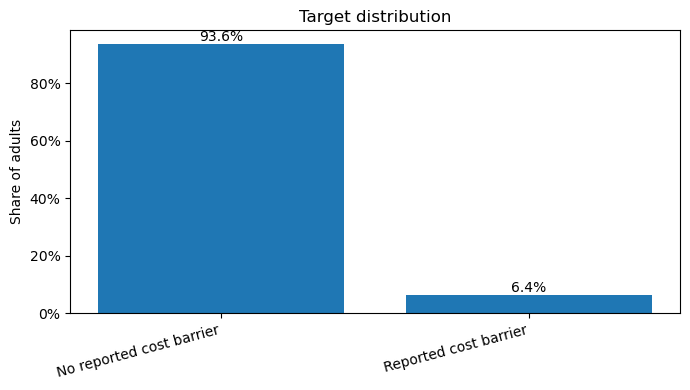

In [11]:
target_plot_df = target_summary.reset_index().rename(columns={
    target_col: "target",
    "proportion": "share"
})

target_plot_df["label"] = target_plot_df["target"].map({
    0: "No reported cost barrier",
    1: "Reported cost barrier",
})

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(target_plot_df["label"], target_plot_df["share"])
ax.set_title("Target distribution")
ax.set_ylabel("Share of adults")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

for i, value in enumerate(target_plot_df["share"]):
    ax.text(i, value, f"{value:.1%}", ha="center", va="bottom")

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Weighted rates by selected features

The next figures show weighted rates of reported cost-related mental health care barriers across selected features. These are descriptive comparisons. They help show which groups had higher reported barriers in the analytic file.

In [12]:
descriptive_features = {
    "poverty_group_imp": "Poverty group",
    "mental_health_history_count": "Mental health history count",
    "affordability_pressure_count": "Affordability pressure count",
    "functioning_difficulty_count": "Functioning difficulty count",
    "DISAB3_A": "Disability status",
    "SEX_A": "Sex",
    "REGION": "Region",
}

weighted_rate_tables = {}

for col, label in descriptive_features.items():
    if col in nhis_fe.columns:
        rate_df = weighted_rate_by_group(
            nhis_fe,
            group_col=col,
            target_col=target_col,
            weight_col="WTFA_A",
            min_count=50,
        )

        weighted_rate_tables[col] = rate_df

        print("\n" + "=" * 80)
        print(label)
        display(rate_df)


Poverty group


,group,unweighted_n,weighted_rate,unweighted_rate
0,Near poor: 100% to <125% FPL,1118,0.086300,0.076923
1,Low income: 125% to <200% FPL,4100,0.080520,0.074390
2,Poor: below 100% FPL,3045,0.078605,0.074220
3,Middle income: 200% to <400% FPL,8450,0.070493,0.067929
4,High income: 400%+ FPL,12064,0.056137,0.053133



Mental health history count


,group,unweighted_n,weighted_rate,unweighted_rate
0,2,3673,0.218844,0.203921
1,1,3619,0.112382,0.107488
2,0,21485,0.034396,0.032302



Affordability pressure count


...

,group,unweighted_n,weighted_rate,unweighted_rate
0,1.0,3072,0.106087,0.087240
1,2.0,25704,0.063249,0.060847



Sex


,group,unweighted_n,weighted_rate,unweighted_rate
0,2.0,15633,0.087452,0.080727
1,1.0,13139,0.045988,0.043154



Region


,group,unweighted_n,weighted_rate,unweighted_rate
0,4,7294,0.080092,0.075679
1,3,10688,0.067526,0.062313
2,2,6338,0.066211,0.060429
3,1,4457,0.050214,0.051829


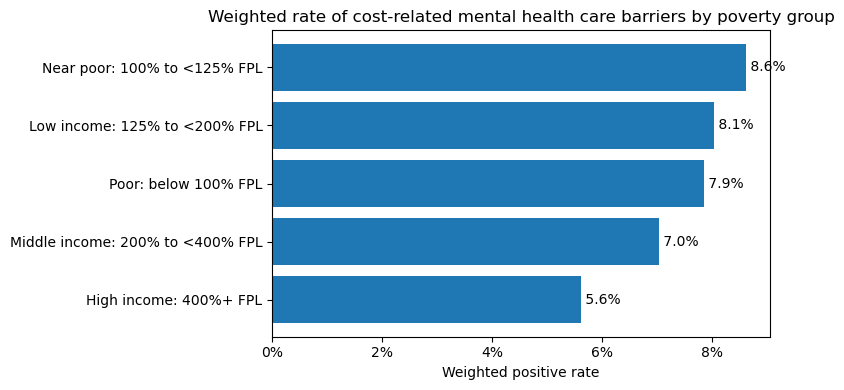

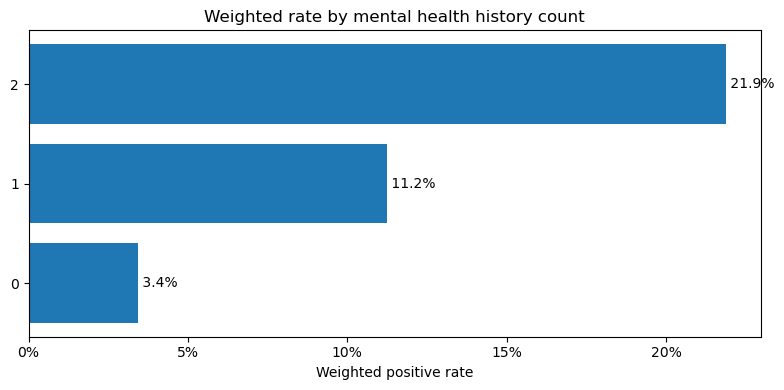

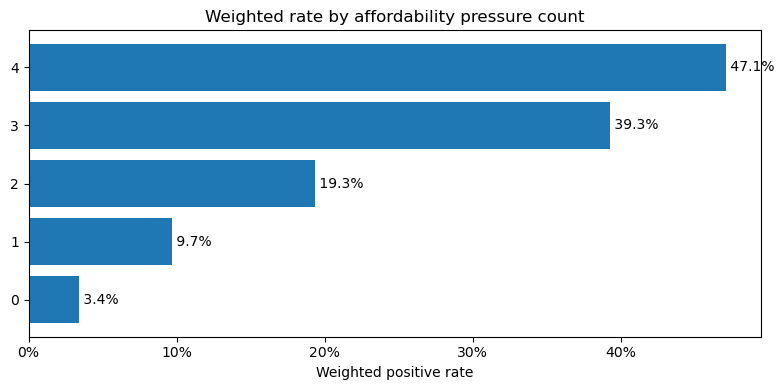

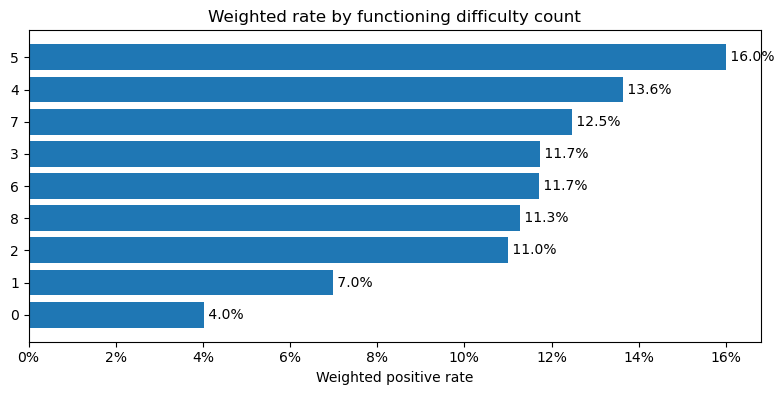

In [13]:
plot_weighted_rate(
    weighted_rate_tables["poverty_group_imp"],
    title="Weighted rate of cost-related mental health care barriers by poverty group"
)

plot_weighted_rate(
    weighted_rate_tables["mental_health_history_count"],
    title="Weighted rate by mental health history count"
)

plot_weighted_rate(
    weighted_rate_tables["affordability_pressure_count"],
    title="Weighted rate by affordability pressure count"
)

plot_weighted_rate(
    weighted_rate_tables["functioning_difficulty_count"],
    title="Weighted rate by functioning difficulty count"
)

## Statistical screening checks

The chi-square tests below check whether the target distribution differs across selected categorical features in the observed analytic file.

These tests are not treated as final survey-adjusted inference. NHIS uses a complex sample design, so formal population inference would require survey-aware variance estimation. Here, the tests are used as descriptive screening checks to support feature review and model interpretation.

In [14]:
screening_features = [
    "poverty_group_imp",
    "mental_health_history_count",
    "affordability_pressure_count",
    "functioning_difficulty_count",
    "DISAB3_A",
    "SEX_A",
    "REGION",
    "insurance_hierarchy_combined",
    "USUALPL_A",
    "LASTDR_A",
]

screening_results = []

for col in screening_features:
    if col in nhis_fe.columns:
        result = chi_square_screen(nhis_fe, col, target_col)

        if result is not None:
            screening_results.append(result)

screening_results_df = (
    pd.DataFrame(screening_results)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

screening_results_df

,feature,chi2,dof,p_value,cramers_v,n_used
0,affordability_pressure_count,3379.310018,4,0.000000e+00,0.342682,28777
1,mental_health_history_count,1683.266334,2,0.000000e+00,0.241854,28777
2,functioning_difficulty_count,339.044585,8,1.970793e-68,0.108544,28777
3,SEX_A,168.670524,1,1.443922e-38,0.076566,28772
4,USUALPL_A,87.553637,2,9.726783e-20,0.055174,28761
5,poverty_group_imp,41.925151,4,1.728831e-08,0.038169,28777
6,LASTDR_A,32.858932,6,1.116192e-05,0.033812,28742
7,DISAB3_A,31.624647,1,1.870405e-08,0.033151,28776
8,REGION,29.576978,3,1.693792e-06,0.032059,28777


## Save descriptive tables

The weighted descriptive tables and statistical screening results are saved for the report and presentation.

In [15]:
for col, table in weighted_rate_tables.items():
    table_path = DATA_PROCESSED / f"nhis_weighted_rate_by_{col}.csv"
    table.to_csv(table_path, index=False)
    print("Saved:", table_path)

screening_results_path = DATA_PROCESSED / "nhis_statistical_screening_checks.csv"
screening_results_df.to_csv(screening_results_path, index=False)

print("Saved:", screening_results_path)

Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_weighted_rate_by_poverty_group_imp.csv
Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_weighted_rate_by_mental_health_history_count.csv
Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_weighted_rate_by_affordability_pressure_count.csv
Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_weighted_rate_by_functioning_difficulty_count.csv
Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_weighted_rate_by_DISAB3_A.csv
Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_weighted_rate_by_SEX_A.csv
Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_weighted_rate_by_REGION.csv
Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_statistical_screening_checks.csv


## Predictor sets

Two model versions are created. The first version uses Sample Adult features plus grouped poverty. The second version adds selected paradata features.

Related raw variables are not added when a clearer engineered count is already used. This keeps the first model easier to explain and reduces duplicate information.

In [16]:
baseline_feature_cols = [
    # Demographics and location
    "AGEP_A",
    "SEX_A",
    "HISPALLP_A",
    "RACEALLP_A",
    "EDUCP_A",
    "REGION",
    "URBRRL",
    "PCNTADLT_A",
    "PCNTKIDS_A",
    "OVER65FLG_A",
    "MLTFAMFLG_A",
    "MAXEDUCP_A",

    # Poverty and socioeconomic context
    "poverty_group_imp",

    # Health need
    "PHSTAT_A",
    "LSATIS4_A",
    "chronic_condition_count",
    "mental_health_history_count",

    # Functioning and disability
    "DISAB3_A",
    "functioning_difficulty_count",

    # Insurance and care access
    "insurance_hierarchy_combined",
    "USUALPL_A",
    "USPLKIND_A",
    "LASTDR_A",
    "VIRAPP12M_A",

    # Broader affordability pressure
    "affordability_pressure_count",
]

paradata_feature_cols = [
    "TOTCOUNT",
    "MODE_P",
    "MODE_T",
    "INTMODESA",
    "INTLANGSA",
    "SASTRPNT",
    "SA_TOD",
    "personal_visit_contact_share",
    "telephone_contact_share",
]

baseline_feature_cols = [col for col in baseline_feature_cols if col in nhis_fe.columns]
paradata_feature_cols = [col for col in paradata_feature_cols if col in nhis_fe.columns]

print("Baseline features:", len(baseline_feature_cols))
print(baseline_feature_cols)

print("\nParadata features:", len(paradata_feature_cols))
print(paradata_feature_cols)

Baseline features: 24
['AGEP_A', 'SEX_A', 'HISPALLP_A', 'RACEALLP_A', 'EDUCP_A', 'REGION', 'URBRRL', 'PCNTADLT_A', 'PCNTKIDS_A', 'OVER65FLG_A', 'MLTFAMFLG_A', 'MAXEDUCP_A', 'poverty_group_imp', 'PHSTAT_A', 'LSATIS4_A', 'chronic_condition_count', 'mental_health_history_count', 'DISAB3_A', 'functioning_difficulty_count', 'USUALPL_A', 'USPLKIND_A', 'LASTDR_A', 'VIRAPP12M_A', 'affordability_pressure_count']

Paradata features: 9
['TOTCOUNT', 'MODE_P', 'MODE_T', 'INTMODESA', 'INTLANGSA', 'SASTRPNT', 'SA_TOD', 'personal_visit_contact_share', 'telephone_contact_share']


## Excluded variables

Identifiers, survey design variables, direct target components, detailed poverty ratio variables, and high-missing paradata fields are excluded from model predictors.

Weights and design variables are retained for weighted descriptive checks and survey-aware sensitivity work, but they are not used as predictors.

In [17]:
excluded_from_predictors = [
    # Identifiers and survey design
    "HHX",
    "WTFA_A",
    "PSTRAT",
    "PPSU",

    # Direct target components
    "MHTHDLY_A",
    "MHTHND_A",

    # Poverty variables not used in the first model
    "RATCAT_A",
    "RATCAT_A_imp",
    "POVRATTC_A",
    "POVRATTC_A_imp_mean",
    "POVRATTC_A_imp_min",
    "POVRATTC_A_imp_max",

    # Raw variables summarized by engineered counts
    "ANXEV_A",
    "DEPEV_A",
    "HYPEV_A",
    "CHLEV_A",
    "DIBEV_A",
    "COPDEV_A",
    "ARTHEV_A",
    "ASEV_A",
    "CANEV_A",
    "STREV_A",
    "CHDEV_A",
    "VISIONDF_A",
    "HEARINGDF_A",
    "DIFF_A",
    "COMDIFF_A",
    "COGMEMDFF_A",
    "UPPSLFCR_A",
    "SOCERRNDS_A",
    "SOCSCLPAR_A",
    "PAYBLL12M_A",
    "PAYWORRY_A",
    "MEDDL12M_A",
    "MEDNG12M_A",

    # High-missing or review-only paradata
    "INTMODEWHYSA",
]

excluded_available = [col for col in excluded_from_predictors if col in nhis_fe.columns]
excluded_available

['HHX',
 'WTFA_A',
 'PSTRAT',
 'PPSU',
 'MHTHDLY_A',
 'MHTHND_A',
 'RATCAT_A',
 'RATCAT_A_imp',
 'POVRATTC_A',
 'POVRATTC_A_imp_mean',
 'POVRATTC_A_imp_min',
 'POVRATTC_A_imp_max',
 'ANXEV_A',
 'DEPEV_A',
 'HYPEV_A',
 'CHLEV_A',
 'DIBEV_A',
 'COPDEV_A',
 'ARTHEV_A',
 'ASEV_A',
 'CANEV_A',
 'STREV_A',
 'CHDEV_A',
 'VISIONDF_A',
 'HEARINGDF_A',
 'DIFF_A',
 'COMDIFF_A',
 'COGMEMDFF_A',
 'UPPSLFCR_A',
 'SOCERRNDS_A',
 'SOCSCLPAR_A',
 'PAYBLL12M_A',
 'PAYWORRY_A',
 'MEDDL12M_A',
 'MEDNG12M_A',
 'INTMODEWHYSA']

## Build model versions

Version A tests the core Sample Adult and grouped poverty features.

Version B adds selected paradata features so the interview process layer can be evaluated instead of assumed to help.

In [18]:
model_versions = {
    "A_baseline_adult_income": baseline_feature_cols,
    "B_baseline_plus_paradata": baseline_feature_cols + paradata_feature_cols,
}

for name, cols in model_versions.items():
    print(name, len(cols))

A_baseline_adult_income 24
B_baseline_plus_paradata 33


## Train/test split

The train/test split is stratified by the target so the smaller positive class is represented in both sets. This is a modeling step only. It does not replace the NHIS survey design variables or the Sample Adult weight.

In [19]:
model_df = nhis_fe.dropna(subset=[target_col]).copy()
model_df[target_col] = model_df[target_col].astype(int)

train_df, test_df = train_test_split(
    model_df,
    test_size=0.25,
    random_state=42,
    stratify=model_df[target_col],
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain target distribution:")
print(train_df[target_col].value_counts(normalize=True).sort_index())

print("\nTest target distribution:")
print(test_df[target_col].value_counts(normalize=True).sort_index())

Train shape: (21582, 84)
Test shape: (7195, 84)

Train target distribution:
mental_health_cost_barrier
0    0.936336
1    0.063664
Name: proportion, dtype: float64

Test target distribution:
mental_health_cost_barrier
0    0.936345
1    0.063655
Name: proportion, dtype: float64


## Preprocessing setup

Categorical variables are one-hot encoded. Numeric variables are median-imputed and scaled for models that benefit from scaling.

Missing predictor values are handled inside the modeling pipeline so the training and test sets are treated consistently.

In [20]:
def split_feature_types(df, feature_cols):
    categorical_cols = []
    numeric_cols = []

    for col in feature_cols:
        if df[col].dtype == "object":
            categorical_cols.append(col)
        else:
            unique_count = df[col].nunique(dropna=True)

            if unique_count <= 15:
                categorical_cols.append(col)
            else:
                numeric_cols.append(col)

    return numeric_cols, categorical_cols


def build_preprocessor(df, feature_cols):
    numeric_cols, categorical_cols = split_feature_types(df, feature_cols)

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipe, numeric_cols),
            ("categorical", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
    )

    return preprocessor, numeric_cols, categorical_cols

## Model set

The first model set includes one interpretable baseline, one simple rule-based model, and two nonlinear ensemble models.

Logistic Regression is the main interpretable baseline.
Decision Tree gives a readable rule-based comparison.
Random Forest captures nonlinear relationships and interactions.
Gradient Boosting provides a stronger tabular prediction benchmark.

For imbalance, class-weighted versions are included where the model supports them. Resampling will be considered only after these first models are checked.

In [21]:
def get_classification_models():
    models = {
        "logistic_regression_balanced": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42,
        ),
        "decision_tree_balanced": DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=50,
            class_weight="balanced",
            random_state=42,
        ),
        "random_forest_balanced": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
        "gradient_boosting": GradientBoostingClassifier(
            random_state=42,
        ),
    }

    return models

## Evaluation function

The evaluation table reports metrics that are useful for an imbalanced access-barrier outcome. Accuracy is included, but it is not the main decision metric.

In [22]:
def evaluate_classifier(model, X_test, y_test):
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_test)[:, 1]
    else:
        score = model.decision_function(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, score),
        "average_precision": average_precision_score(y_test, score),
    }

    return metrics

## Objective 1: Best predictive model

The first objective compares models based on overall predictive performance. Because the positive class is small, AUC and average precision are more useful than accuracy alone. Recall, precision, and F1-score are also reported so the tradeoff between missed barriers and false positives is visible.

This objective tests two feature versions: adult and income features only, then adult, income, and selected paradata features.

In [23]:
model_results = []
trained_models = {}

for version_name, feature_cols in model_versions.items():
    print("\n" + "=" * 100)
    print(version_name)
    print("=" * 100)

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    preprocessor, numeric_cols, categorical_cols = build_preprocessor(
        train_df,
        feature_cols
    )

    print("Numeric features:", len(numeric_cols))
    print("Categorical features:", len(categorical_cols))

    models = get_classification_models()

    for model_name, clf in models.items():
        print(f"\nTraining {model_name}...")

        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", clf),
        ])

        pipe.fit(X_train, y_train)

        metrics = evaluate_classifier(pipe, X_test, y_test)

        result = {
            "version": version_name,
            "model": model_name,
            "n_features": len(feature_cols),
            **metrics,
        }

        model_results.append(result)
        trained_models[(version_name, model_name)] = pipe

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    ["roc_auc", "average_precision", "f1"],
    ascending=False
).reset_index(drop=True)

results_df


A_baseline_adult_income
Numeric features: 1
Categorical features: 23

Training logistic_regression_balanced...

Training decision_tree_balanced...

Training random_forest_balanced...

Training gradient_boosting...

B_baseline_plus_paradata
Numeric features: 6
Categorical features: 27

Training logistic_regression_balanced...

Training decision_tree_balanced...

Training random_forest_balanced...

Training gradient_boosting...


,version,model,n_features,accuracy,precision,recall,f1,roc_auc,average_precision
0,A_baseline_adult_income,random_forest_balanced,24,0.839055,0.244152,0.729258,0.365827,0.875886,0.399396
1,B_baseline_plus_paradata,random_forest_balanced,33,0.851981,0.257781,0.705240,0.377557,0.875602,0.401842
2,B_baseline_plus_paradata,gradient_boosting,33,0.940931,0.612245,0.196507,0.297521,0.875470,0.400622
3,A_baseline_adult_income,gradient_boosting,24,0.940514,0.607143,0.185590,0.284281,0.875286,0.402557
4,A_baseline_adult_income,logistic_regression_balanced,24,0.809312,0.217553,0.768559,0.339114,0.874892,0.396194
5,B_baseline_plus_paradata,logistic_regression_balanced,33,0.810980,0.219178,0.768559,0.341085,0.874341,0.399079
6,A_baseline_adult_income,decision_tree_balanced,24,0.823489,0.224185,0.720524,0.341969,0.852030,0.316302
7,B_baseline_plus_paradata,decision_tree_balanced,33,0.823489,0.224185,0.720524,0.341969,0.851804,0.311792


## Objective 1 model comparison

The comparison table shows whether the added paradata features improve predictive performance. If performance is nearly the same, the simpler adult and income model is preferred because it is easier to explain.

In [24]:
display_cols = [
    "version",
    "model",
    "n_features",
    "roc_auc",
    "average_precision",
    "recall",
    "precision",
    "f1",
    "accuracy",
]

results_df[display_cols]

,version,model,n_features,roc_auc,average_precision,recall,precision,f1,accuracy
0,A_baseline_adult_income,random_forest_balanced,24,0.875886,0.399396,0.729258,0.244152,0.365827,0.839055
1,B_baseline_plus_paradata,random_forest_balanced,33,0.875602,0.401842,0.705240,0.257781,0.377557,0.851981
2,B_baseline_plus_paradata,gradient_boosting,33,0.875470,0.400622,0.196507,0.612245,0.297521,0.940931
3,A_baseline_adult_income,gradient_boosting,24,0.875286,0.402557,0.185590,0.607143,0.284281,0.940514
4,A_baseline_adult_income,logistic_regression_balanced,24,0.874892,0.396194,0.768559,0.217553,0.339114,0.809312
5,B_baseline_plus_paradata,logistic_regression_balanced,33,0.874341,0.399079,0.768559,0.219178,0.341085,0.810980
6,A_baseline_adult_income,decision_tree_balanced,24,0.852030,0.316302,0.720524,0.224185,0.341969,0.823489
7,B_baseline_plus_paradata,decision_tree_balanced,33,0.851804,0.311792,0.720524,0.224185,0.341969,0.823489


## Objective 1 recommended model

The first recommended model is selected by AUC, with average precision, recall, precision, and F1-score used to check whether the result is reasonable for an imbalanced access-barrier outcome.

In [25]:
best_row = results_df.iloc[0]

best_version = best_row["version"]
best_model_name = best_row["model"]
best_model = trained_models[(best_version, best_model_name)]

print("Best version:", best_version)
print("Best model:", best_model_name)
print(best_row[display_cols])

Best version: A_baseline_adult_income
Best model: random_forest_balanced
version              A_baseline_adult_income
model                 random_forest_balanced
n_features                                24
roc_auc                             0.875886
average_precision                   0.399396
recall                              0.729258
precision                           0.244152
f1                                  0.365827
accuracy                            0.839055
Name: 0, dtype: object


## Objective 1 confusion matrix

The confusion matrix shows how many adults in the held-out test set were classified correctly or incorrectly using the default threshold.

In [26]:
best_features = model_versions[best_version]

X_test_best = test_df[best_features]
y_test = test_df[target_col]

best_pred = best_model.predict(X_test_best)

cm = confusion_matrix(y_test, best_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual no barrier", "Actual barrier"],
    columns=["Predicted no barrier", "Predicted barrier"]
)

cm_df

,Predicted no barrier,Predicted barrier
Actual no barrier,5703,1034
Actual barrier,124,334


In [27]:
print(classification_report(
    y_test,
    best_pred,
    target_names=["No cost barrier", "Cost barrier"],
    zero_division=0
))

                 precision    recall  f1-score   support

No cost barrier       0.98      0.85      0.91      6737
   Cost barrier       0.24      0.73      0.37       458

       accuracy                           0.84      7195
      macro avg       0.61      0.79      0.64      7195
   weighted avg       0.93      0.84      0.87      7195



## Objective 1 threshold review

The default threshold is 0.50. For an imbalanced access-barrier outcome, that threshold may not give the best balance between recall and precision.

The threshold table shows what happens when the cutoff is lowered or raised. A lower threshold usually finds more true cost-barrier cases but also increases false positives.

In [28]:
if hasattr(best_model, "predict_proba"):
    best_scores = best_model.predict_proba(X_test_best)[:, 1]
else:
    best_scores = best_model.decision_function(X_test_best)

threshold_rows = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    threshold_pred = (best_scores >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, threshold_pred, zero_division=0),
        "recall": recall_score(y_test, threshold_pred, zero_division=0),
        "f1": f1_score(y_test, threshold_pred, zero_division=0),
        "predicted_positive_rate": threshold_pred.mean(),
    })

threshold_df = pd.DataFrame(threshold_rows)

threshold_df

,threshold,precision,recall,f1,predicted_positive_rate
0,0.10,0.084181,0.993450,0.155211,0.751216
1,0.15,0.096649,0.975983,0.175880,0.642808
2,0.20,0.110354,0.954148,0.197827,0.550382
3,0.25,0.128076,0.943231,0.225529,0.468798
4,0.30,0.145965,0.908297,0.251511,0.396108
5,0.40,0.190597,0.823144,0.309524,0.274913
6,0.50,0.244152,0.729258,0.365827,0.190132


## Objective 1 interpretation

The strongest first benchmark is the balanced Random Forest using the adult and imputed-income feature set. It reached an AUC of 0.876 and identified about 73% of adults in the held-out test set who reported a cost-related mental health care barrier.

Precision is lower because the positive class is small. This means many adults flagged by the model did not report the barrier. For this reason, the model should be interpreted as a population-level screening or pattern-finding tool, not as an individual decision tool.

The paradata version did not materially improve performance. Because the adult and income version is simpler and performs nearly the same, it is the better first candidate for reporting.

## Objective 1 feature importance

Feature importance is reviewed for the best Random Forest benchmark. These values show which encoded features contributed most to prediction in the model. They should be interpreted as model signals, not causal effects.

In [29]:
def get_feature_names_from_pipeline(pipeline):
    preprocessor = pipeline.named_steps["preprocessor"]
    return preprocessor.get_feature_names_out()


model_step = best_model.named_steps["model"]

if not hasattr(model_step, "feature_importances_"):
    raise AttributeError(
        f"{best_model_name} does not have feature_importances_. "
        "Feature importance in this format is only available for tree-based models."
    )

feature_names = get_feature_names_from_pipeline(best_model)

importances = pd.DataFrame({
    "feature": feature_names,
    "importance": model_step.feature_importances_,
})

importances = importances.sort_values("importance", ascending=False).reset_index(drop=True)

importances.head(25)

,feature,importance
0,categorical__affordability_pressure_count_0,0.130113
1,numeric__AGEP_A,0.127976
2,categorical__mental_health_history_count_0,0.106484
3,categorical__mental_health_history_count_2,0.055872
4,categorical__OVER65FLG_A_1,0.043970
5,categorical__OVER65FLG_A_0,0.039661
6,categorical__LSATIS4_A_1.0,0.036648
7,categorical__affordability_pressure_count_3,0.030110
8,categorical__affordability_pressure_count_4,0.020771
9,categorical__functioning_difficulty_count_0,0.020129


In [30]:
importance_path = DATA_PROCESSED / "nhis_objective1_random_forest_feature_importance.csv"

importances.to_csv(importance_path, index=False)

print("Saved:", importance_path)

Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_objective1_random_forest_feature_importance.csv


## Save Objective 1 results

The Objective 1 comparison table, threshold review, and feature importance table are saved for the report and presentation.

In [31]:
results_path = DATA_PROCESSED / "nhis_objective1_model_comparison_results.csv"
threshold_path = DATA_PROCESSED / "nhis_objective1_threshold_review.csv"

results_df.to_csv(results_path, index=False)
threshold_df.to_csv(threshold_path, index=False)

print("Saved:", results_path)
print("Saved:", threshold_path)
print("Saved:", importance_path)

Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_objective1_model_comparison_results.csv
Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_objective1_threshold_review.csv
Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_objective1_random_forest_feature_importance.csv


## Objective 2: Best interpretable model

The second objective focuses on interpretability. The goal is to identify a model that can be explained clearly to technical and nontechnical readers while still performing reasonably well on the held-out test set.

This objective uses the simpler adult and imputed-income feature set from Version A. The paradata layer is not used here because Objective 1 showed that it did not materially improve predictive performance, and the added interview-process variables make interpretation harder.

The main evaluation criteria are AUC, recall, F1-score, and explanation quality. A model does not need to be the highest-performing model overall to be useful for this objective. It should be understandable enough to support a clear project recommendation.

In [32]:
objective2_features = model_versions["A_baseline_adult_income"]

X_train_obj2 = train_df[objective2_features]
y_train_obj2 = train_df[target_col]

X_test_obj2 = test_df[objective2_features]
y_test_obj2 = test_df[target_col]

preprocessor_obj2, numeric_cols_obj2, categorical_cols_obj2 = build_preprocessor(
    train_df,
    objective2_features
)

print("Objective 2 features:", len(objective2_features))
print("Numeric features:", numeric_cols_obj2)
print("Categorical features:", categorical_cols_obj2)

Objective 2 features: 24
Numeric features: ['AGEP_A']
Categorical features: ['SEX_A', 'HISPALLP_A', 'RACEALLP_A', 'EDUCP_A', 'REGION', 'URBRRL', 'PCNTADLT_A', 'PCNTKIDS_A', 'OVER65FLG_A', 'MLTFAMFLG_A', 'MAXEDUCP_A', 'poverty_group_imp', 'PHSTAT_A', 'LSATIS4_A', 'chronic_condition_count', 'mental_health_history_count', 'DISAB3_A', 'functioning_difficulty_count', 'USUALPL_A', 'USPLKIND_A', 'LASTDR_A', 'VIRAPP12M_A', 'affordability_pressure_count']


## Objective 2 model set

The interpretable model set uses constrained or simpler versions of the same main model families. This keeps the comparison consistent with Objective 1 while changing the priority from maximum prediction to explanation.

The models are:

- Logistic Regression with class weighting
- Logistic Regression without class weighting
- Shallow Decision Tree with class weighting
- Shallow Decision Tree without class weighting

The logistic models support coefficient-based explanation. The shallow trees support rule-based explanation. The class-weighted versions respond to the small positive class, while the unweighted versions provide a simpler baseline comparison.

In [33]:
objective2_models = {
    "logistic_regression_balanced": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42,
    ),
    "logistic_regression_unweighted": LogisticRegression(
        max_iter=2000,
        class_weight=None,
        solver="lbfgs",
        random_state=42,
    ),
    "shallow_tree_balanced": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=100,
        class_weight="balanced",
        random_state=42,
    ),
    "shallow_tree_unweighted": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=100,
        class_weight=None,
        random_state=42,
    ),
}

## Train and evaluate Objective 2 models

Each model is trained on the same training data and evaluated on the same held-out test data. The comparison keeps the metrics from Objective 1 but adds an interpretation note for each model family.

In [34]:
objective2_results = []
objective2_trained_models = {}

for model_name, clf in objective2_models.items():
    print(f"Training {model_name}...")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_obj2),
        ("model", clf),
    ])

    pipe.fit(X_train_obj2, y_train_obj2)

    metrics = evaluate_classifier(pipe, X_test_obj2, y_test_obj2)

    objective2_results.append({
        "objective": "Objective 2: interpretable model",
        "model": model_name,
        "n_features": len(objective2_features),
        **metrics,
    })

    objective2_trained_models[model_name] = pipe

objective2_results_df = pd.DataFrame(objective2_results)

objective2_results_df = objective2_results_df.sort_values(
    ["roc_auc", "f1", "recall"],
    ascending=False
).reset_index(drop=True)

objective2_results_df[[
    "objective",
    "model",
    "n_features",
    "roc_auc",
    "average_precision",
    "recall",
    "precision",
    "f1",
    "accuracy",
]]

Training logistic_regression_balanced...
Training logistic_regression_unweighted...
Training shallow_tree_balanced...
Training shallow_tree_unweighted...


,objective,model,n_features,roc_auc,average_precision,recall,precision,f1,accuracy
0,Objective 2: interpretable model,logistic_regression_unweighted,24,0.876080,0.400434,0.185590,0.562914,0.279146,0.938985
1,Objective 2: interpretable model,logistic_regression_balanced,24,0.874892,0.396194,0.768559,0.217553,0.339114,0.809312
2,Objective 2: interpretable model,shallow_tree_unweighted,24,0.853832,0.297781,0.150655,0.482517,0.229617,0.935650
3,Objective 2: interpretable model,shallow_tree_balanced,24,0.849458,0.291552,0.740175,0.211347,0.328807,0.807644


## Objective 2 recommendation

The recommended interpretable model is the balanced Logistic Regression model. The unweighted Logistic Regression has slightly higher AUC, but it identifies far fewer adults with a reported cost-related mental health care barrier.

For this project, recall matters because the positive class is small and the target represents a reported access barrier. The balanced Logistic Regression model is still interpretable through coefficients, and it better reflects the class imbalance problem.

In [35]:
objective2_best_model_name = "logistic_regression_balanced"
objective2_best_model = objective2_trained_models[objective2_best_model_name]

objective2_best_row = objective2_results_df[
    objective2_results_df["model"] == objective2_best_model_name
].iloc[0]

print("Objective 2 recommended model:", objective2_best_model_name)
print(objective2_best_row)

Objective 2 recommended model: logistic_regression_balanced
objective            Objective 2: interpretable model
model                    logistic_regression_balanced
n_features                                         24
accuracy                                     0.809312
precision                                    0.217553
recall                                       0.768559
f1                                           0.339114
roc_auc                                      0.874892
average_precision                            0.396194
Name: 1, dtype: object


## Objective 2 confusion matrix

The confusion matrix shows how the recommended interpretable model performs at the default threshold. If recall is too low, threshold tuning can be reviewed, but the main purpose of this objective is explanation rather than maximum screening performance.

In [36]:
objective2_pred = objective2_best_model.predict(X_test_obj2)

objective2_cm = confusion_matrix(y_test_obj2, objective2_pred)

objective2_cm_df = pd.DataFrame(
    objective2_cm,
    index=["Actual no barrier", "Actual barrier"],
    columns=["Predicted no barrier", "Predicted barrier"]
)

objective2_cm_df

,Predicted no barrier,Predicted barrier
Actual no barrier,5471,1266
Actual barrier,106,352


In [37]:
print(classification_report(
    y_test_obj2,
    objective2_pred,
    target_names=["No cost barrier", "Cost barrier"],
    zero_division=0
))

                 precision    recall  f1-score   support

No cost barrier       0.98      0.81      0.89      6737
   Cost barrier       0.22      0.77      0.34       458

       accuracy                           0.81      7195
      macro avg       0.60      0.79      0.61      7195
   weighted avg       0.93      0.81      0.85      7195



## Save Objective 2 results

The Objective 2 model comparison table is saved for the report and presentation.

In [38]:
objective2_results_path = DATA_PROCESSED / "nhis_objective2_interpretable_model_results.csv"

objective2_results_df.to_csv(objective2_results_path, index=False)

print("Saved:", objective2_results_path)

Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_objective2_interpretable_model_results.csv


## Objective 3: Lift and cost-sensitive screening model

The third objective focuses on finding adults who are more likely to report a cost-related mental health care barrier. This objective is useful when resources are limited and the goal is to prioritize outreach, screening, or further review.

The positive class is small, so this objective compares several imbalance strategies:

- class weighting, which penalizes mistakes on the minority class more heavily
- threshold tuning, which changes the probability cutoff for classification
- training-only undersampling, which reduces the majority class in the training data
- training-only oversampling, which duplicates minority-class training cases

The test set is never resampled. This keeps evaluation realistic.

In [39]:
from sklearn.utils import resample

In [40]:
objective3_features = model_versions["A_baseline_adult_income"]

X_train_obj3 = train_df[objective3_features].copy()
y_train_obj3 = train_df[target_col].copy()

X_test_obj3 = test_df[objective3_features].copy()
y_test_obj3 = test_df[target_col].copy()

preprocessor_obj3, numeric_cols_obj3, categorical_cols_obj3 = build_preprocessor(
    train_df,
    objective3_features
)

print("Objective 3 features:", len(objective3_features))
print("Training target distribution:")
print(y_train_obj3.value_counts(normalize=True).sort_index())

Objective 3 features: 24
Training target distribution:
mental_health_cost_barrier
0    0.936336
1    0.063664
Name: proportion, dtype: float64


## Training-only resampling sets

Resampling is applied only to the training data. The held-out test set keeps the original class distribution.

In [41]:
train_obj3 = train_df[objective3_features + [target_col]].copy()

majority_train = train_obj3[train_obj3[target_col] == 0]
minority_train = train_obj3[train_obj3[target_col] == 1]

majority_downsampled = resample(
    majority_train,
    replace=False,
    n_samples=len(minority_train),
    random_state=42,
)

train_undersampled = pd.concat([majority_downsampled, minority_train]).sample(
    frac=1,
    random_state=42,
)

minority_oversampled = resample(
    minority_train,
    replace=True,
    n_samples=len(majority_train),
    random_state=42,
)

train_oversampled = pd.concat([majority_train, minority_oversampled]).sample(
    frac=1,
    random_state=42,
)

print("Original training shape:", train_obj3.shape)
print("Undersampled training shape:", train_undersampled.shape)
print("Oversampled training shape:", train_oversampled.shape)

print("\nUndersampled target distribution:")
print(train_undersampled[target_col].value_counts(normalize=True).sort_index())

print("\nOversampled target distribution:")
print(train_oversampled[target_col].value_counts(normalize=True).sort_index())

Original training shape: (21582, 25)
Undersampled training shape: (2748, 25)
Oversampled training shape: (40416, 25)

Undersampled target distribution:
mental_health_cost_barrier
0    0.5
1    0.5
Name: proportion, dtype: float64

Oversampled target distribution:
mental_health_cost_barrier
0    0.5
1    0.5
Name: proportion, dtype: float64


## Objective 3 helper functions

Lift is calculated by ranking adults by predicted probability and checking how concentrated true cost-barrier cases are in the top-ranked group. A lift greater than 1 means the model finds more true barrier cases than random selection.

In [42]:
def evaluate_scores_at_threshold(y_true, scores, threshold):
    pred = (scores >= threshold).astype(int)

    return {
        "threshold": threshold,
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "predicted_positive_rate": pred.mean(),
    }


def lift_at_percent(y_true, scores, top_percent):
    lift_df = pd.DataFrame({
        "y_true": y_true.values,
        "score": scores,
    }).sort_values("score", ascending=False)

    n_top = int(np.ceil(len(lift_df) * top_percent))
    top_group = lift_df.head(n_top)

    top_rate = top_group["y_true"].mean()
    base_rate = lift_df["y_true"].mean()

    return top_rate / base_rate

## Objective 3 model set

The model set compares several imbalance strategies. These are not meant to replace Objective 1. They answer a different question: which approach is better for identifying a higher-risk group under class imbalance?

In [43]:
objective3_configs = {
    "logistic_balanced": {
        "train_df": train_obj3,
        "model": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42,
        ),
        "fit_sample_weight": None,
    },
    "random_forest_balanced": {
        "train_df": train_obj3,
        "model": RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
        "fit_sample_weight": None,
    },
    "logistic_undersampled": {
        "train_df": train_undersampled,
        "model": LogisticRegression(
            max_iter=2000,
            class_weight=None,
            solver="lbfgs",
            random_state=42,
        ),
        "fit_sample_weight": None,
    },
    "logistic_oversampled": {
        "train_df": train_oversampled,
        "model": LogisticRegression(
            max_iter=2000,
            class_weight=None,
            solver="lbfgs",
            random_state=42,
        ),
        "fit_sample_weight": None,
    },
    "gradient_boosting_weighted_loss": {
        "train_df": train_obj3,
        "model": GradientBoostingClassifier(
            random_state=42,
        ),
        "fit_sample_weight": "balanced",
    },
}

## Train and evaluate Objective 3 models

Each model is evaluated with AUC, average precision, recall, F1-score, and lift in the top 10%, 20%, and 30% of predicted risk.

In [44]:
objective3_results = []
objective3_trained_models = {}

for model_name, config in objective3_configs.items():
    print(f"Training {model_name}...")

    train_data = config["train_df"]

    X_train_current = train_data[objective3_features]
    y_train_current = train_data[target_col]

    preprocessor_current, _, _ = build_preprocessor(
        train_data,
        objective3_features
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_current),
        ("model", config["model"]),
    ])

    if config["fit_sample_weight"] == "balanced":
        class_counts = y_train_current.value_counts()
        sample_weight = y_train_current.map({
            0: len(y_train_current) / (2 * class_counts[0]),
            1: len(y_train_current) / (2 * class_counts[1]),
        })

        pipe.fit(X_train_current, y_train_current, model__sample_weight=sample_weight)
    else:
        pipe.fit(X_train_current, y_train_current)

    if hasattr(pipe, "predict_proba"):
        scores = pipe.predict_proba(X_test_obj3)[:, 1]
    else:
        scores = pipe.decision_function(X_test_obj3)

    default_pred = (scores >= 0.50).astype(int)

    objective3_results.append({
        "objective": "Objective 3: lift/cost-sensitive screening",
        "model": model_name,
        "roc_auc": roc_auc_score(y_test_obj3, scores),
        "average_precision": average_precision_score(y_test_obj3, scores),
        "precision_050": precision_score(y_test_obj3, default_pred, zero_division=0),
        "recall_050": recall_score(y_test_obj3, default_pred, zero_division=0),
        "f1_050": f1_score(y_test_obj3, default_pred, zero_division=0),
        "lift_top_10pct": lift_at_percent(y_test_obj3, scores, 0.10),
        "lift_top_20pct": lift_at_percent(y_test_obj3, scores, 0.20),
        "lift_top_30pct": lift_at_percent(y_test_obj3, scores, 0.30),
    })

    objective3_trained_models[model_name] = pipe

objective3_results_df = pd.DataFrame(objective3_results)

objective3_results_df = objective3_results_df.sort_values(
    ["lift_top_20pct", "roc_auc", "average_precision"],
    ascending=False
).reset_index(drop=True)

objective3_results_df

Training logistic_balanced...
Training random_forest_balanced...
Training logistic_undersampled...
Training logistic_oversampled...
Training gradient_boosting_weighted_loss...


,objective,model,roc_auc,average_precision,precision_050,recall_050,f1_050,lift_top_10pct,lift_top_20pct,lift_top_30pct
0,Objective 3: lift/cost-sensitive screening,random_forest_balanced,0.875886,0.399396,0.244152,0.729258,0.365827,5.301992,3.711790,2.837771
1,Objective 3: lift/cost-sensitive screening,gradient_boosting_weighted_loss,0.873975,0.395547,0.217391,0.775109,0.339550,5.389268,3.711790,2.815942
2,Objective 3: lift/cost-sensitive screening,logistic_balanced,0.874892,0.396194,0.217553,0.768559,0.339114,5.389268,3.700873,2.845047
3,Objective 3: lift/cost-sensitive screening,logistic_oversampled,0.873022,0.393628,0.216667,0.766376,0.337825,5.367449,3.700873,2.845047
4,Objective 3: lift/cost-sensitive screening,logistic_undersampled,0.874297,0.384540,0.216637,0.790393,0.340066,5.236536,3.657205,2.830494


## Objective 3 recommendation

The recommended model for this objective is selected by lift in the top 20% of predicted risk, with AUC and average precision used as supporting checks. This reflects a screening or outreach use case where the goal is to concentrate likely cost-barrier cases in a smaller group for follow-up.

In [45]:
objective3_best_row = objective3_results_df.iloc[0]

objective3_best_model_name = objective3_best_row["model"]
objective3_best_model = objective3_trained_models[objective3_best_model_name]

print("Objective 3 recommended model:", objective3_best_model_name)
print(objective3_best_row)

Objective 3 recommended model: random_forest_balanced
objective            Objective 3: lift/cost-sensitive screening
model                                    random_forest_balanced
roc_auc                                                0.875886
average_precision                                      0.399396
precision_050                                          0.244152
recall_050                                             0.729258
f1_050                                                 0.365827
lift_top_10pct                                         5.301992
lift_top_20pct                                          3.71179
lift_top_30pct                                         2.837771
Name: 0, dtype: object


## Objective 3 interpretation

The lift results show that the recommended model concentrates cost-barrier cases much more effectively than random selection. A lift of about 3.7 in the top 20% means that the highest-scored fifth of adults contains more than three times the expected share of reported cost-related mental health care barriers.

The models perform similarly by AUC, so the recommendation is based on lift and screening usefulness rather than overall ranking performance alone. This is different from Objective 1, where the goal was the strongest general predictive benchmark.

## Objective 3 threshold review

The threshold review shows how the recommended Objective 3 model behaves under different cutoffs. This supports the cost-sensitive framing because false negatives and false positives may matter differently depending on the use case.

In [46]:
if hasattr(objective3_best_model, "predict_proba"):
    objective3_scores = objective3_best_model.predict_proba(X_test_obj3)[:, 1]
else:
    objective3_scores = objective3_best_model.decision_function(X_test_obj3)

objective3_threshold_rows = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    row = evaluate_scores_at_threshold(y_test_obj3, objective3_scores, threshold)
    objective3_threshold_rows.append(row)

objective3_threshold_df = pd.DataFrame(objective3_threshold_rows)

objective3_threshold_df

,threshold,precision,recall,f1,predicted_positive_rate
0,0.10,0.084181,0.993450,0.155211,0.751216
1,0.15,0.096649,0.975983,0.175880,0.642808
2,0.20,0.110354,0.954148,0.197827,0.550382
3,0.25,0.128076,0.943231,0.225529,0.468798
4,0.30,0.145965,0.908297,0.251511,0.396108
5,0.40,0.190597,0.823144,0.309524,0.274913
6,0.50,0.244152,0.729258,0.365827,0.190132


## Save Objective 3 results

The Objective 3 comparison table and threshold review are saved for the report and presentation.

In [47]:
objective3_results_path = DATA_PROCESSED / "nhis_objective3_lift_cost_sensitive_results.csv"
objective3_threshold_path = DATA_PROCESSED / "nhis_objective3_threshold_review.csv"

objective3_results_df.to_csv(objective3_results_path, index=False)
objective3_threshold_df.to_csv(objective3_threshold_path, index=False)

print("Saved:", objective3_results_path)
print("Saved:", objective3_threshold_path)

Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_objective3_lift_cost_sensitive_results.csv
Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_objective3_threshold_review.csv


## Modeling checkpoint

Part I now includes three classification objectives. Each objective trains and compares at least four candidate models, uses metrics tied to the objective, and recommends a model based on the project context.

The modeling results are saved for the report, presentation, and later scoring workflow.

In [48]:
modeling_checkpoint = pd.DataFrame({
    "objective": [
        "Objective 1: Best predictive model",
        "Objective 2: Best interpretable model",
        "Objective 3: Lift/cost-sensitive screening",
    ],
    "models_trained": [
        len(results_df),
        len(objective2_results_df),
        len(objective3_results_df),
    ],
    "recommended_model": [
        best_model_name,
        objective2_best_model_name,
        objective3_best_model_name,
    ],
})

modeling_checkpoint

,objective,models_trained,recommended_model
0,Objective 1: Best predictive model,8,random_forest_balanced
1,Objective 2: Best interpretable model,4,logistic_regression_balanced
2,Objective 3: Lift/cost-sensitive screening,5,random_forest_balanced


## Save modeling checkpoint

The final checkpoint table is saved so the report can clearly show how Part I met the modeling requirements.

In [49]:
checkpoint_path = DATA_PROCESSED / "nhis_modeling_checkpoint.csv"

modeling_checkpoint.to_csv(checkpoint_path, index=False)

print("Saved:", checkpoint_path)

Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_modeling_checkpoint.csv


## NHIS score dataset

The score dataset simulates how the selected models would score new records. The target and direct target component variables are removed before scoring.

A 30-row sample is created from the held-out test set. The original target is kept only in a private validation copy and is not exported in the scoring input file.

The exported score output includes model probabilities and predicted labels for the three project objectives.

In [50]:
score_n = 30

score_sample = test_df.sample(n=score_n, random_state=340).copy()

score_id = pd.Series(
    [f"NHIS_SCORE_{i:03d}" for i in range(1, score_n + 1)],
    index=score_sample.index,
    name="score_id"
)

score_validation = pd.DataFrame({
    "score_id": score_id,
    "actual_target_hidden_check": score_sample[target_col],
})

score_validation.head()

,score_id,actual_target_hidden_check
27032,NHIS_SCORE_001,0
3239,NHIS_SCORE_002,0
13439,NHIS_SCORE_003,0
7440,NHIS_SCORE_004,0
3348,NHIS_SCORE_005,0


## Build scoring input file

The scoring input file removes the target and direct target components. It keeps only the fields needed to score the selected models, plus a generated score ID.

In [51]:
score_input_cols = sorted(set(
    model_versions["A_baseline_adult_income"]
    + model_versions["B_baseline_plus_paradata"]
))

score_input = score_sample[score_input_cols].copy()
score_input.insert(0, "score_id", score_id.values)

blocked_score_cols = [
    target_col,
    "MHTHDLY_A",
    "MHTHND_A",
    "HHX",
    "WTFA_A",
    "PSTRAT",
    "PPSU",
]

blocked_present = [col for col in blocked_score_cols if col in score_input.columns]

print("Score input shape:", score_input.shape)
print("Blocked columns found in score input:", blocked_present)

score_input.head()

Score input shape: (30, 34)
Blocked columns found in score input: []


,score_id,AGEP_A,DISAB3_A,EDUCP_A,HISPALLP_A,INTLANGSA,INTMODESA,LASTDR_A,LSATIS4_A,MAXEDUCP_A,...,USPLKIND_A,USUALPL_A,VIRAPP12M_A,affordability_pressure_count,chronic_condition_count,functioning_difficulty_count,mental_health_history_count,personal_visit_contact_share,poverty_group_imp,telephone_contact_share
27032,NHIS_SCORE_001,28.0,2.0,6.0,3,1.0,3.0,1.0,2.0,6.0,...,1.0,1.0,1.0,0,0,1,0,0.571429,Poor: below 100% FPL,0.428571
3239,NHIS_SCORE_002,27.0,1.0,8.0,2,1.0,3.0,1.0,2.0,8.0,...,NaN,2.0,1.0,0,1,3,2,1.000000,Poor: below 100% FPL,0.000000
13439,NHIS_SCORE_003,53.0,2.0,9.0,1,1.0,3.0,1.0,3.0,9.0,...,1.0,1.0,1.0,1,3,2,1,1.000000,High income: 400%+ FPL,0.000000
7440,NHIS_SCORE_004,75.0,2.0,4.0,1,3.0,1.0,1.0,1.0,4.0,...,1.0,1.0,1.0,0,3,3,1,0.333333,Near poor: 100% to <125% FPL,0.666667
3348,NHIS_SCORE_005,54.0,2.0,4.0,2,1.0,1.0,1.0,1.0,4.0,...,1.0,1.0,2.0,1,0,0,0,0.666667,Low income: 125% to <200% FPL,0.333333


## Score selected models

Each selected model scores the same 30 records. The score represents the predicted probability of a reported cost-related mental health care barrier.

Objective 1 uses the best predictive model.  
Objective 2 uses the balanced interpretable model.  
Objective 3 uses the lift/cost-sensitive screening model.

In [52]:
def get_positive_class_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


score_output = score_input[["score_id"]].copy()

# Objective 1
X_score_obj1 = score_sample[model_versions[best_version]]
score_output["objective1_model"] = best_model_name
score_output["objective1_probability"] = get_positive_class_scores(best_model, X_score_obj1)
score_output["objective1_predicted_label_050"] = (
    score_output["objective1_probability"] >= 0.50
).astype(int)

# Objective 2
X_score_obj2 = score_sample[objective2_features]
score_output["objective2_model"] = objective2_best_model_name
score_output["objective2_probability"] = get_positive_class_scores(objective2_best_model, X_score_obj2)
score_output["objective2_predicted_label_050"] = (
    score_output["objective2_probability"] >= 0.50
).astype(int)

# Objective 3
X_score_obj3 = score_sample[objective3_features]
score_output["objective3_model"] = objective3_best_model_name
score_output["objective3_probability"] = get_positive_class_scores(objective3_best_model, X_score_obj3)
score_output["objective3_predicted_label_050"] = (
    score_output["objective3_probability"] >= 0.50
).astype(int)

score_output = score_output.sort_values(
    "objective3_probability",
    ascending=False
).reset_index(drop=True)

score_output["objective3_rank"] = np.arange(1, len(score_output) + 1)
score_output["objective3_top_20pct_flag"] = (
    score_output["objective3_rank"] <= np.ceil(len(score_output) * 0.20)
).astype(int)

score_output.head(10)

,score_id,objective1_model,objective1_probability,objective1_predicted_label_050,objective2_model,objective2_probability,objective2_predicted_label_050,objective3_model,objective3_probability,objective3_predicted_label_050,objective3_rank,objective3_top_20pct_flag
0,NHIS_SCORE_012,random_forest_balanced,0.777446,1,logistic_regression_balanced,0.981115,1,random_forest_balanced,0.777446,1,1,1
1,NHIS_SCORE_002,random_forest_balanced,0.704301,1,logistic_regression_balanced,0.883276,1,random_forest_balanced,0.704301,1,2,1
2,NHIS_SCORE_003,random_forest_balanced,0.689272,1,logistic_regression_balanced,0.949353,1,random_forest_balanced,0.689272,1,3,1
3,NHIS_SCORE_009,random_forest_balanced,0.661279,1,logistic_regression_balanced,0.615261,1,random_forest_balanced,0.661279,1,4,1
4,NHIS_SCORE_023,random_forest_balanced,0.615957,1,logistic_regression_balanced,0.459981,0,random_forest_balanced,0.615957,1,5,1
5,NHIS_SCORE_007,random_forest_balanced,0.511020,1,logistic_regression_balanced,0.642416,1,random_forest_balanced,0.511020,1,6,1
6,NHIS_SCORE_001,random_forest_balanced,0.487061,0,logistic_regression_balanced,0.653297,1,random_forest_balanced,0.487061,0,7,0
7,NHIS_SCORE_021,random_forest_balanced,0.342323,0,logistic_regression_balanced,0.260130,0,random_forest_balanced,0.342323,0,8,0
8,NHIS_SCORE_024,random_forest_balanced,0.316371,0,logistic_regression_balanced,0.195969,0,random_forest_balanced,0.316371,0,9,0
9,NHIS_SCORE_029,random_forest_balanced,0.304529,0,logistic_regression_balanced,0.247824,0,random_forest_balanced,0.304529,0,10,0


## Score output check

The scoring output should have 30 rows and should not include the original target. The hidden validation file is kept separate only so the team can check the workflow during development.

In [53]:
print("Score input shape:", score_input.shape)
print("Score output shape:", score_output.shape)

print("\nColumns in score output:")
print(score_output.columns.tolist())

print("\nPredicted positive counts at 0.50 threshold:")
print(score_output[[
    "objective1_predicted_label_050",
    "objective2_predicted_label_050",
    "objective3_predicted_label_050",
]].sum())

Score input shape: (30, 34)
Score output shape: (30, 12)

Columns in score output:
['score_id', 'objective1_model', 'objective1_probability', 'objective1_predicted_label_050', 'objective2_model', 'objective2_probability', 'objective2_predicted_label_050', 'objective3_model', 'objective3_probability', 'objective3_predicted_label_050', 'objective3_rank', 'objective3_top_20pct_flag']

Predicted positive counts at 0.50 threshold:
objective1_predicted_label_050    6
objective2_predicted_label_050    6
objective3_predicted_label_050    6
dtype: int64


## Save score files

The score input file, score output file, and hidden validation file are saved for the final submission workflow.

The score input file does not include the target. The hidden validation file is kept separate only for internal checking during development.

In [54]:
score_input_path = DATA_PROCESSED / "nhis_score_input_30_no_target.csv"
score_output_path = DATA_PROCESSED / "nhis_score_output_30_predictions.csv"
score_validation_path = DATA_PROCESSED / "nhis_score_validation_hidden_target.csv"

score_input.to_csv(score_input_path, index=False)
score_output.to_csv(score_output_path, index=False)
score_validation.to_csv(score_validation_path, index=False)

print("Saved:", score_input_path)
print("Saved:", score_output_path)
print("Saved:", score_validation_path)

Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_score_input_30_no_target.csv
Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_score_output_30_predictions.csv
Saved: C:\Users\Alexi\projects\med_project\data\processed\nhis_score_validation_hidden_target.csv
